In [61]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(303)
n = 300
cols = ["temperature","vibration","pressure","hours"]
x = rng.normal(size=(n,4))
group = rng.choice(["G1","G2"], size=n)
score = x @ np.array([0.7,1.2,-0.5,0.6])
score += 0.4 * (group == "G2") + rng.normal(0,1,n)
y = (score > 0).astype(int)

df = pd.DataFrame(np.round(50 + 10*x,2), columns=cols)
df.insert(0,"record_id",np.arange(1,n+1))
df["group"] = group
df["defect"] = y

for col in cols[:2]:
    df.loc[rng.choice(n,15,replace=False),col] = np.nan

df = pd.concat([df,df.iloc[:5]],ignore_index=True)

Path("data/raw").mkdir(parents=True,exist_ok=True)
df.to_csv("data/raw/set_c.csv",index=False)

df = pd.read_csv("data/raw/set_c.csv")


In [62]:
print(df.shape)

(305, 7)


In [63]:
print(df.head())


   record_id  temperature  vibration  pressure  hours group  defect
0          1        42.32      45.54     41.26  52.36    G1       0
1          2        43.23      66.24     39.51  39.90    G2       1
2          3        36.83      54.02     38.36  60.67    G1       1
3          4        42.13      57.42     69.23  42.21    G1       0
4          5        18.91      56.40     56.39  49.44    G2       0


In [64]:
print(df.isna().sum())


record_id       0
temperature    15
vibration      15
pressure        0
hours           0
group           0
defect          0
dtype: int64


In [65]:
print("duplicates",df.duplicated().sum())


duplicates 5


In [66]:
print(df["defect"].value_counts())

defect
1    175
0    130
Name: count, dtype: int64


Maths and Advanced Statistics

In [67]:
from scipy import stats
from sklearn.model_selection import train_test_split

df = df.drop_duplicates().reset_index(drop=True)

fit_df,test_df = train_test_split(
    df,test_size=0.20,stratify=df["defect"],random_state=42
)

fit_df,val_df = train_test_split(
    fit_df,test_size=0.20,stratify=fit_df["defect"],random_state=42
)


In [68]:
print("fit",fit_df.shape)
print("validation",val_df.shape)
print("test",test_df.shape)
print("unique records",df["record_id"].nunique())

fit (192, 7)
validation (48, 7)
test (60, 7)
unique records 300


In [69]:
print("missing")
print(df.isna().sum())
print("target")
print(df["defect"].value_counts())

missing
record_id       0
temperature    15
vibration      15
pressure        0
hours           0
group           0
defect          0
dtype: int64
target
defect
1    173
0    127
Name: count, dtype: int64


In [70]:
temperature = fit_df["temperature"].dropna()

In [71]:
print("n",len(temperature))
print("mean",temperature.mean())
print("median",temperature.median())
print("std",temperature.std(ddof=1))

n 182
mean 50.37186813186813
median 50.635
std 9.460243582778306


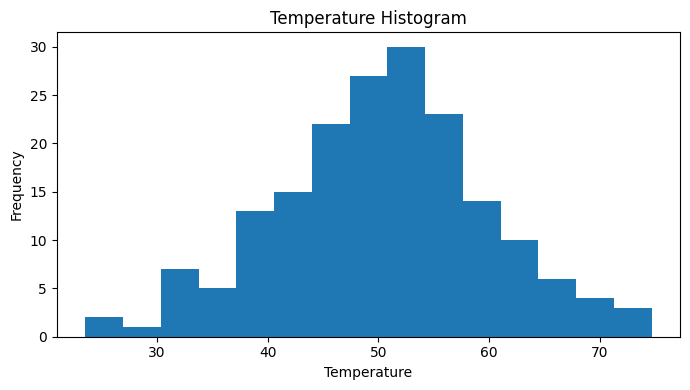

In [72]:
plt.figure(figsize=(7,4))
plt.hist(temperature,bins=15)
plt.title("Temperature Histogram")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("temperature_histogram.png")
plt.show()

In [73]:
g1 = fit_df.loc[fit_df["group"]=="G1","temperature"].dropna()
g2 = fit_df.loc[fit_df["group"]=="G2","temperature"].dropna()

t,p = stats.ttest_ind(g1,g2,equal_var=False)

print("G1 count",len(g1))
print("G2 count",len(g2))
print("t statistic",t)
print("p value",p)

G1 count 103
G2 count 79
t statistic -0.18249675153389958
p value 0.8554114177066398


In [74]:
ci = stats.t.interval(
    0.95,
    len(temperature)-1,
    loc=temperature.mean(),
    scale=stats.sem(temperature)
)

print("95 percent confidence interval",ci)

print("H0: mean temperature is same for G1 and G2")
print("H1: mean temperature is different for G1 and G2")
print("alpha = 0.05")

95 percent confidence interval (np.float64(48.988211666951166), np.float64(51.7555245967851))
H0: mean temperature is same for G1 and G2
H1: mean temperature is different for G1 and G2
alpha = 0.05


Data Preprocessing & Feature Engineering

In [75]:
print("Shape:", df.shape)

print("\nExact duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df["defect"].value_counts())

Shape: (300, 7)

Exact duplicate rows: 0

Missing values:
record_id       0
temperature    15
vibration      15
pressure        0
hours           0
group           0
defect          0
dtype: int64

Target distribution:
defect
1    173
0    127
Name: count, dtype: int64


In [76]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

print("Cleaned shape:", df_clean.shape)
print("Unique rows:", df_clean.drop_duplicates().shape[0])

assert df_clean.shape[0] == 300
assert df_clean.duplicated().sum() == 0

Cleaned shape: (300, 7)
Unique rows: 300


In [77]:
from sklearn.model_selection import train_test_split

fit, temp = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    stratify=df_clean["defect"]
)

validation, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=42,
    stratify=temp["defect"]
)

In [78]:
fit_ids = fit["record_id"].tolist()
validation_ids = validation["record_id"].tolist()
test_ids = test["record_id"].tolist()

pd.Series(fit_ids).to_csv("fit_ids.csv", index=False)
pd.Series(validation_ids).to_csv("validation_ids.csv", index=False)
pd.Series(test_ids).to_csv("test_ids.csv", index=False)

In [79]:
fit_set = set(fit_ids)
validation_set = set(validation_ids)
test_set = set(test_ids)

assert fit_set.isdisjoint(validation_set)
assert fit_set.isdisjoint(test_set)
assert validation_set.isdisjoint(test_set)

print("Fit ∩ Validation:", fit_set & validation_set)
print("Fit ∩ Test:", fit_set & test_set)
print("Validation ∩ Test:", validation_set & test_set)

print("Total unique IDs:",
      len(fit_set | validation_set | test_set))


Fit ∩ Validation: set()
Fit ∩ Test: set()
Validation ∩ Test: set()
Total unique IDs: 300


In [85]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_cols = ["temperature","vibration","pressure","hours"]

imputer = SimpleImputer(strategy="median")

fit_num = imputer.fit_transform(fit_df[num_cols])
val_num = imputer.transform(val_df[num_cols])
test_num = imputer.transform(test_df[num_cols])

fit_original = pd.DataFrame(fit_num,columns=num_cols)
val_original = pd.DataFrame(val_num,columns=num_cols)
test_original = pd.DataFrame(test_num,columns=num_cols)

fit_original["engineered_feature"] = fit_original["vibration"] * fit_original["pressure"]
val_original["engineered_feature"] = val_original["vibration"] * val_original["pressure"]
test_original["engineered_feature"] = test_original["vibration"] * test_original["pressure"]

scale_cols = num_cols + ["engineered_feature"]

scaler = StandardScaler()
fit_scaled = scaler.fit_transform(fit_original[scale_cols])
val_scaled = scaler.transform(val_original[scale_cols])
test_scaled = scaler.transform(test_original[scale_cols])


X_fit = np.column_stack([fit_scaled])
X_val = np.column_stack([val_scaled])
X_test = np.column_stack([test_scaled])

y_fit = fit_df["defect"].to_numpy()
y_val = val_df["defect"].to_numpy()
y_test = test_df["defect"].to_numpy()


In [87]:
print(X_fit.shape)
print(X_test.shape)

(192, 5)
(60, 5)


Supervised Learning

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

log_model = LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(X_fit,y_fit)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

def get_scores(y_true,pred):
    return {
        "accuracy":accuracy_score(y_true,pred),
        "precision":precision_score(y_true,pred,zero_division=0),
        "recall":recall_score(y_true,pred,zero_division=0),
        "f1":f1_score(y_true,pred,zero_division=0)
    }

print("logistic",get_scores(y_test,log_pred))

logistic {'accuracy': 0.7666666666666667, 'precision': 0.8, 'recall': 0.8, 'f1': 0.8}


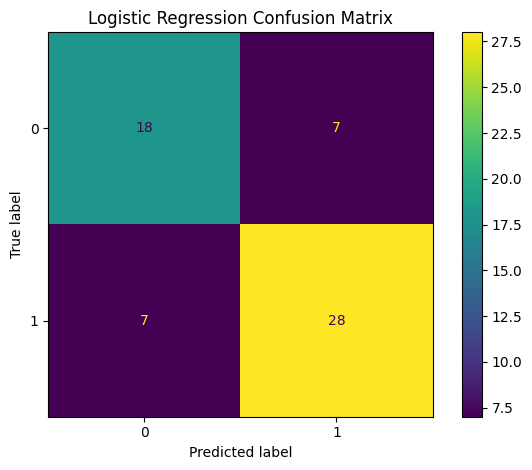

In [90]:
cm = confusion_matrix(y_test,log_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
Path("outputs/figures").mkdir(parents=True,exist_ok=True)
plt.savefig("outputs/figures/confusion_matrix.png")
plt.show()

 Unsupervised Learning

In [98]:
from sklearn.cluster import KMeans
import pandas as pd

fit_scaled = fit_scaled

fit_original_filtered = fit_original.copy()
scale_cols = ["temperature", "vibration", "pressure", "hours", "engineered_feature"]

cluster_results = []

for k in [2,3,4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(fit_scaled)
    inertia = km.inertia_
    cluster_results.append([k, inertia])
    print(f"k={k}, inertia={inertia:.2f}")

km = KMeans(n_init=10, random_state=42)
labels = km.fit_predict(fit_scaled)

cluster_data = fit_original_filtered.copy()
cluster_data["cluster"] = labels

profile = cluster_data.groupby("cluster")[scale_cols].mean()
print(profile)


k=2, inertia=727.29
k=3, inertia=610.28
k=4, inertia=543.64
         temperature  vibration   pressure      hours  engineered_feature
cluster                                                                  
0          49.613750  38.895714  53.782500  53.320714         2080.865871
1          60.274219  49.055937  49.920938  53.239063         2437.338053
2          44.541786  57.430357  51.243214  55.970357         2931.586929
3          53.591136  54.336364  42.068182  36.181364         2275.585814
4          34.942000  50.582667  49.379333  38.508000         2490.178260
5          55.404286  36.890714  40.997143  49.235000         1514.254536
6          51.229107  53.585357  59.838571  45.836786         3195.594211
7          47.827600  53.237600  36.422800  57.576000         1927.927256
